In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

## 1. Data Exploration:

### a. Load the dataset and perform exploratory data analysis (EDA).

In [3]:
df=pd.read_csv("diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### b. Examine the features, their types, and summary statistics.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.shape

(768, 9)

In [9]:
df["Pregnancies"].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

In [10]:
df.iloc[:,6:9:2]

,DiabetesPedigreeFunction,Outcome
0,0.627,1
1,0.351,0
2,0.672,1
3,0.167,0
4,2.288,1
...,...,...
763,0.171,0
764,0.340,0
765,0.245,0
766,0.349,1


### c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

#### Histplot for all columns

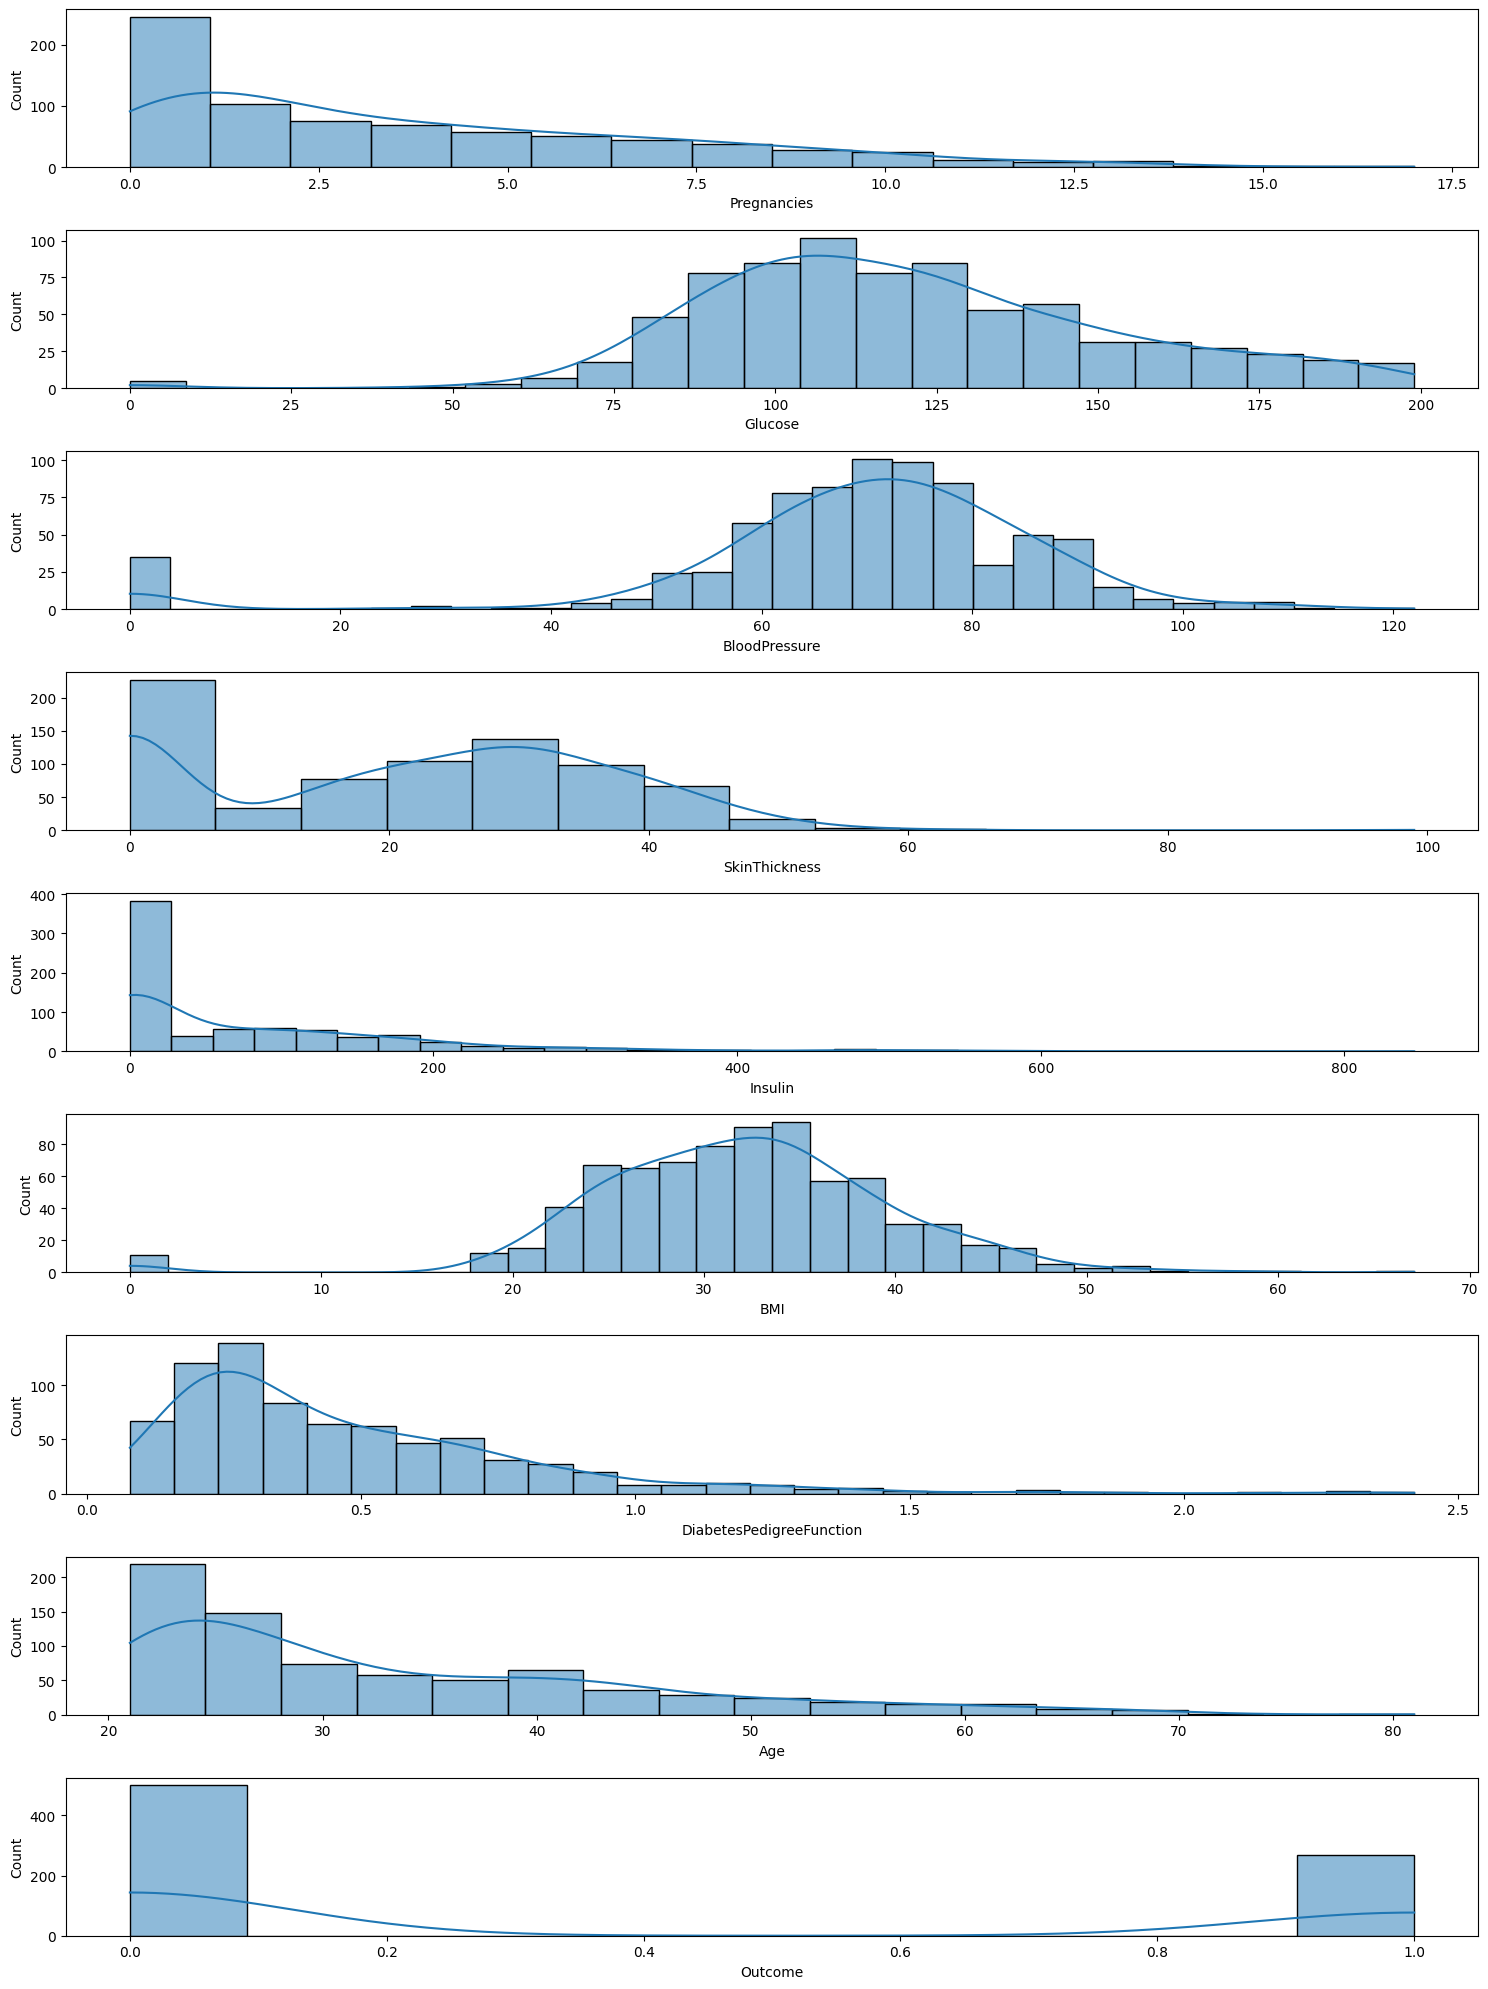

In [11]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(df.columns):
    plt.subplot(len(df.columns), 1, i + 1)
    sns.histplot(df[col], kde=True)
plt.tight_layout()
plt.show()

### Observations:
1. Columns with normal distribution : Glucose, BloodPressure, BMI
2. Columns with skewness :Pregnancies, SkinThickness, DiabetesPedigreeFunction, Age

#### BoxPlot For All Columns

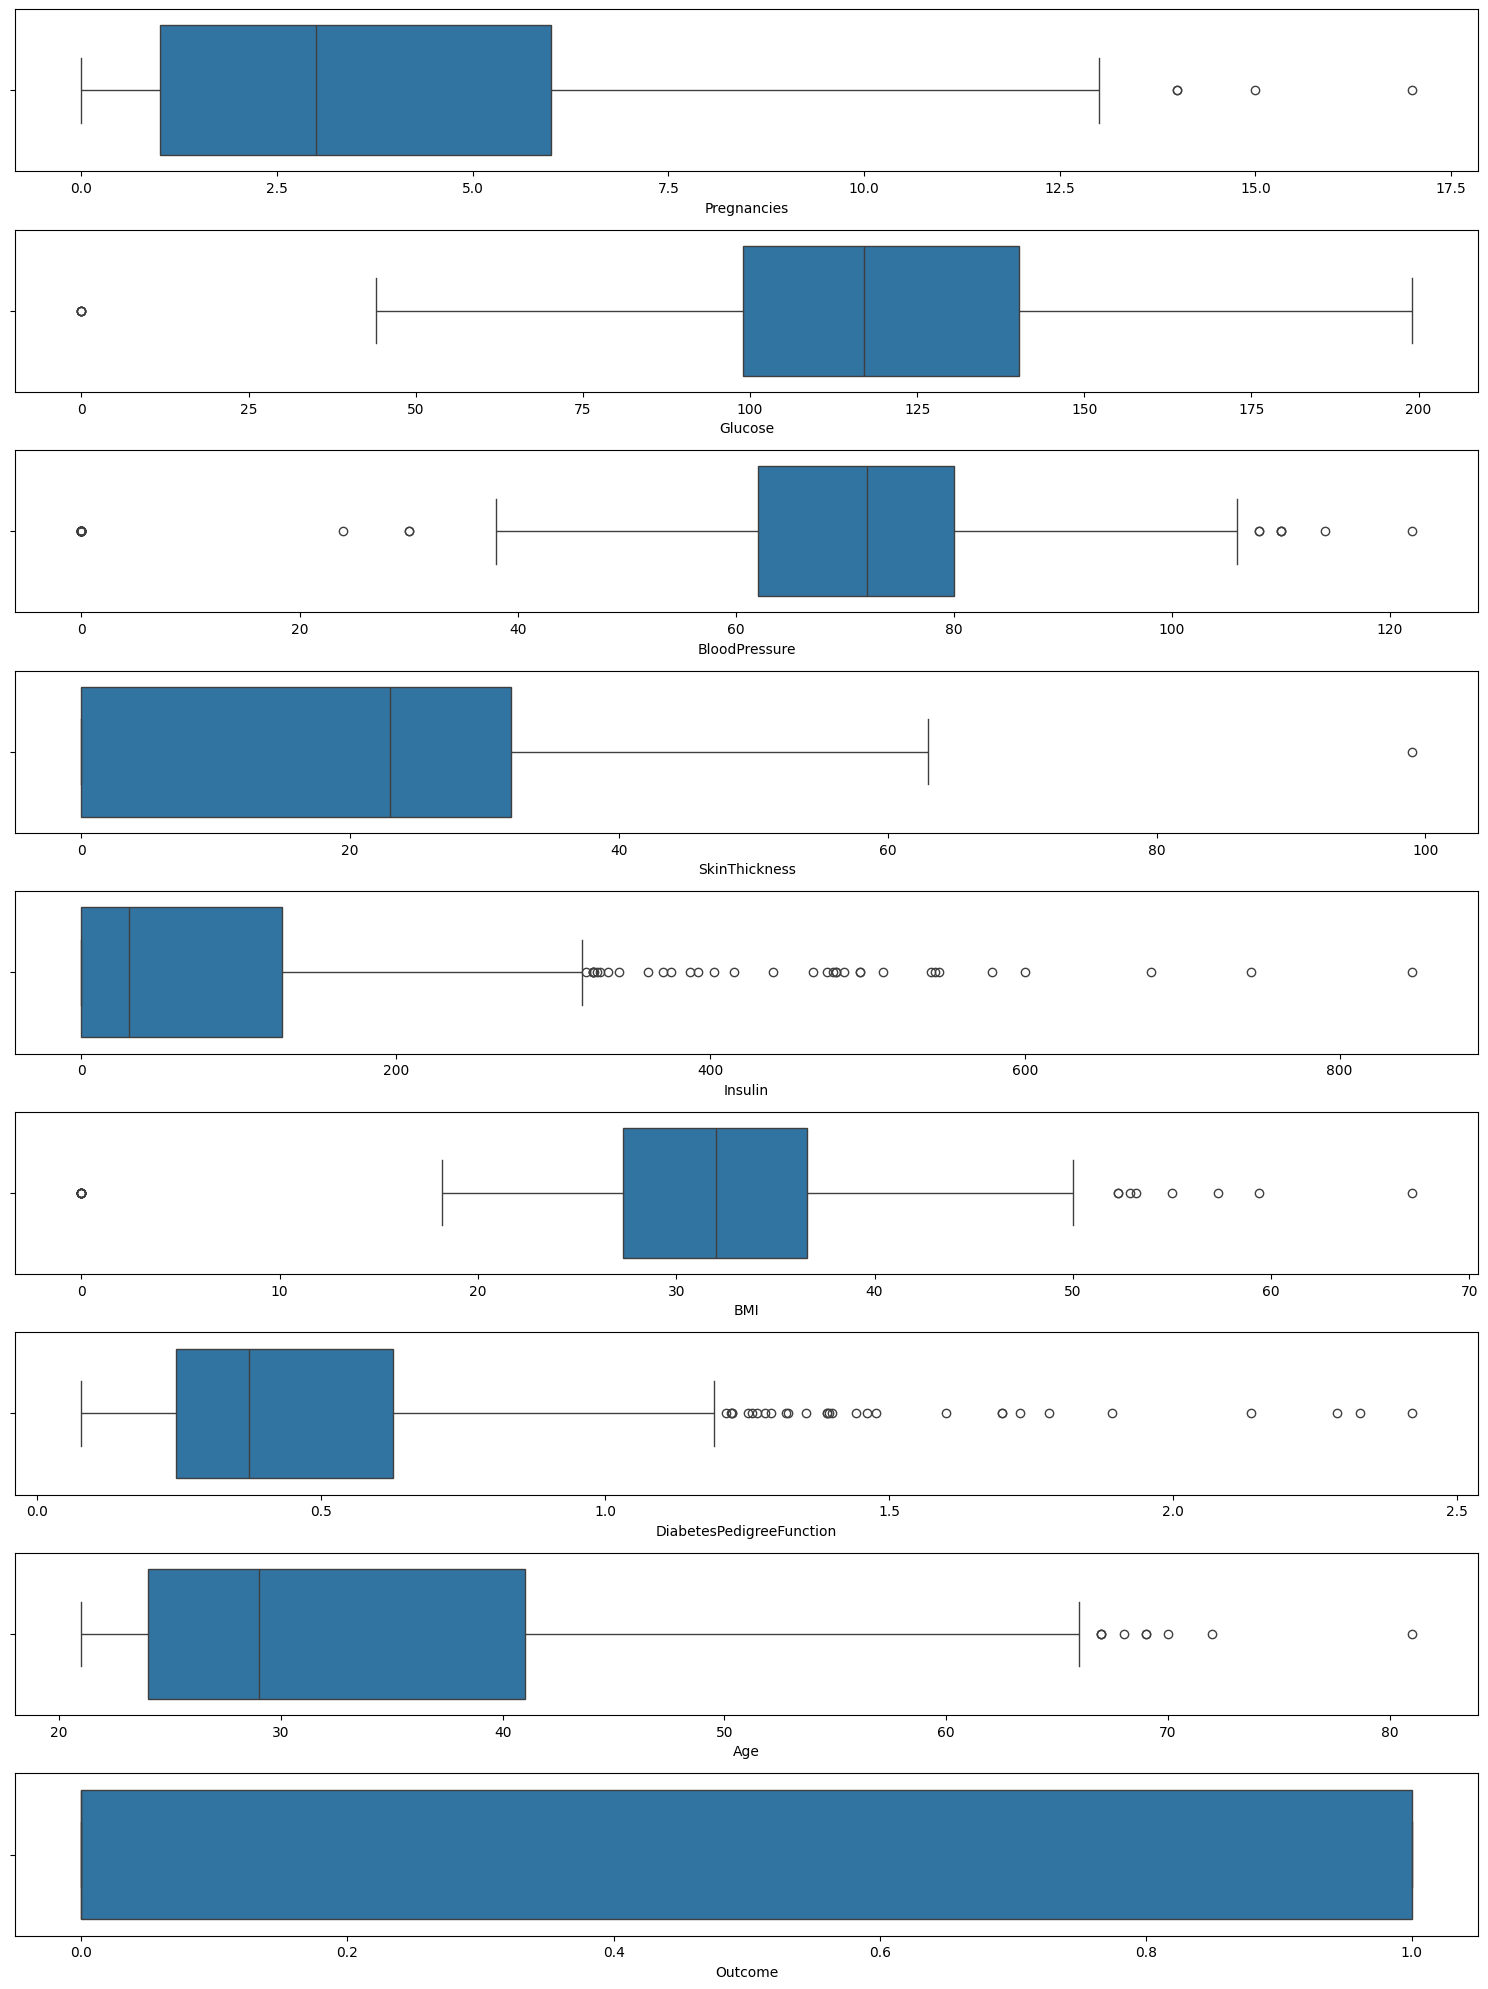

In [12]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(df.columns):
    plt.subplot(len(df.columns), 1, i + 1)
    sns.boxplot(x=df[col])
plt.tight_layout()
plt.show()

#### Observations:
1. Columns Containing Outliers : Pregnancies, BloodPressure, Insulin, BMI, DiabetesPedigreeFunction, Age

2. Columns Which have very lesss Outliers :Glucose, SkinThickness

#### Scatter Plot For All Columns

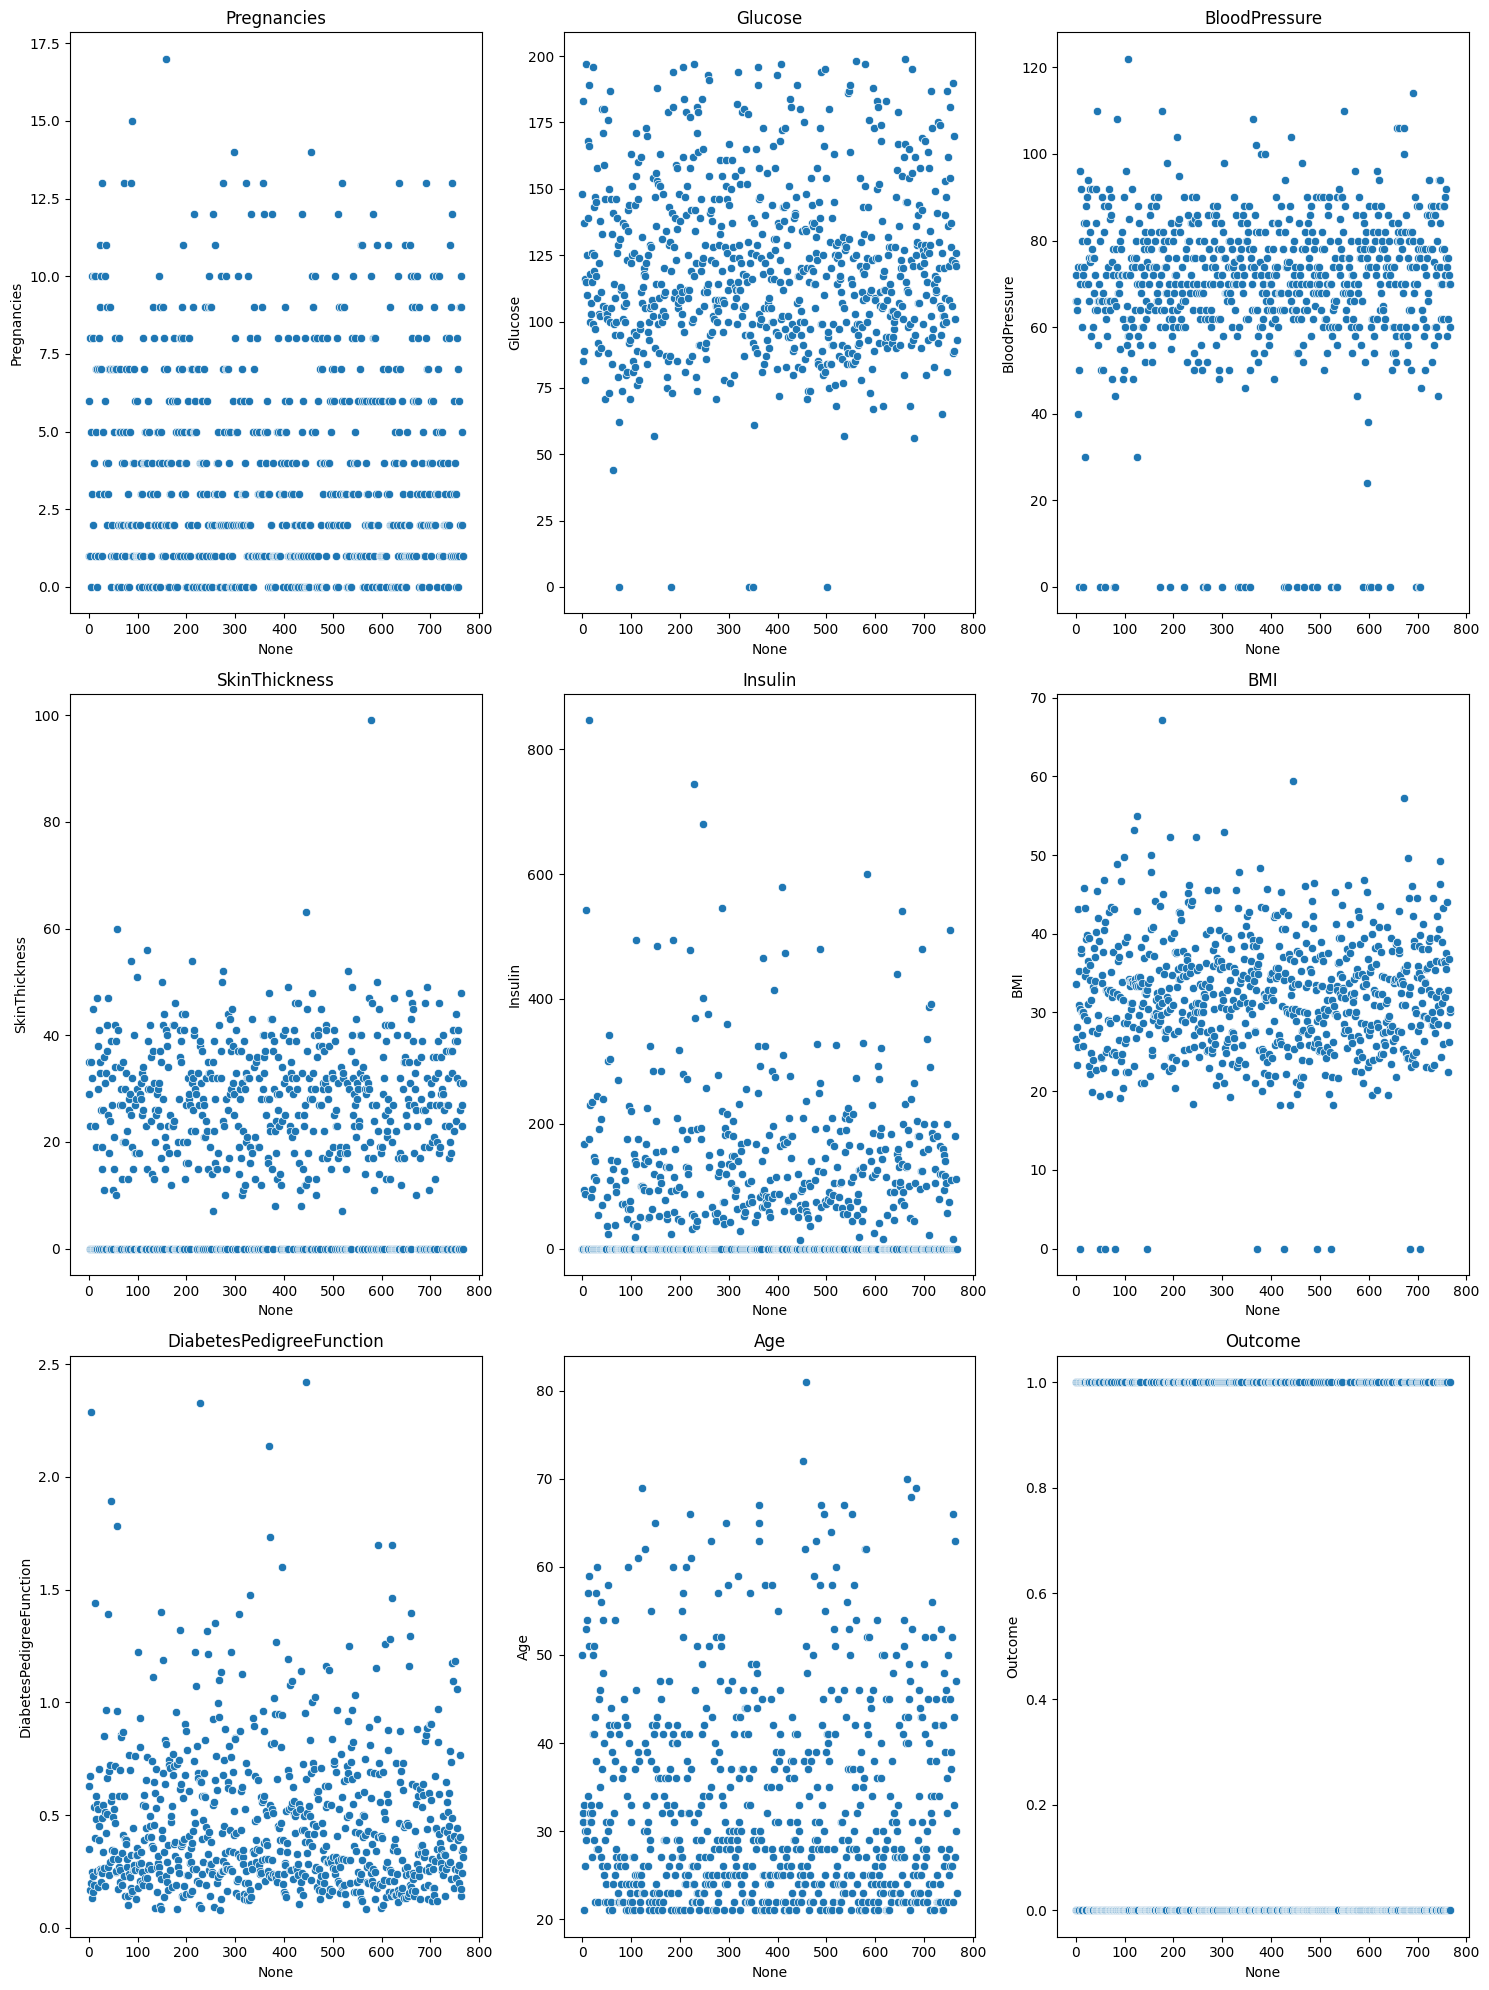

In [13]:
import math
n_cols = 3
n_rows = math.ceil(len(df.columns) / n_cols)

plt.figure(figsize=(15, 20))

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=df.index, y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


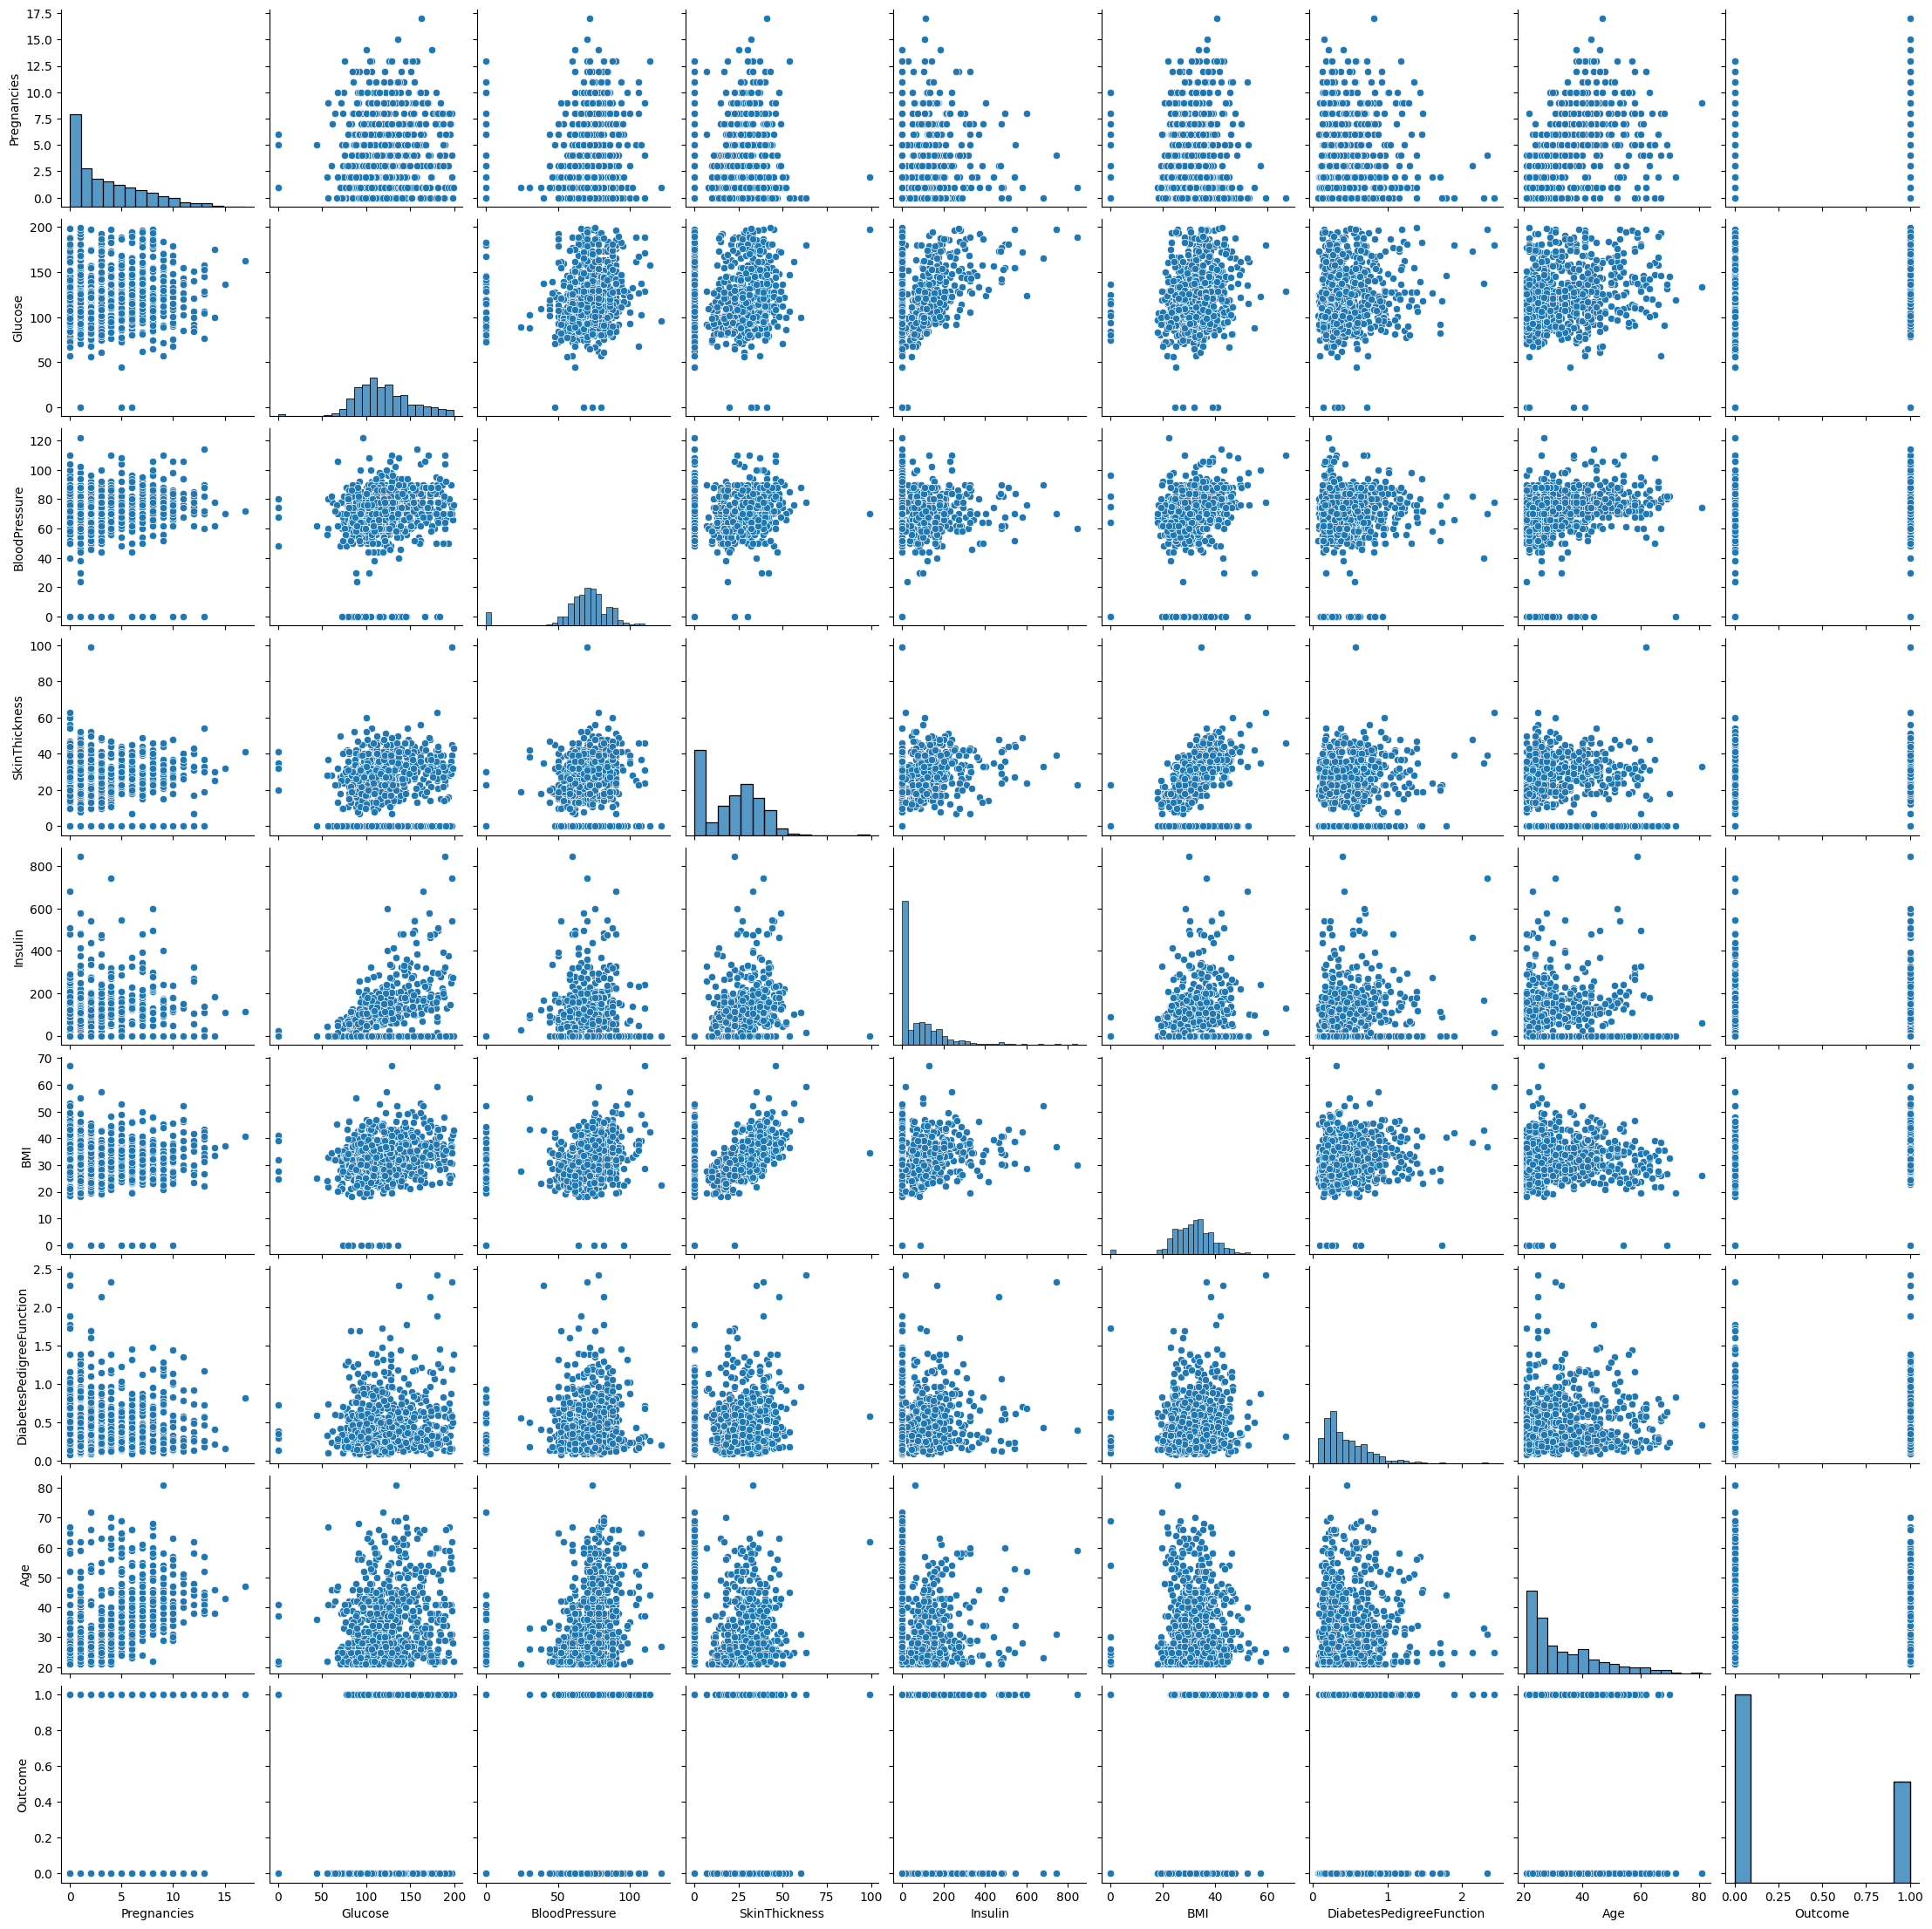

In [14]:
sns.pairplot(data=df)

<Axes: >

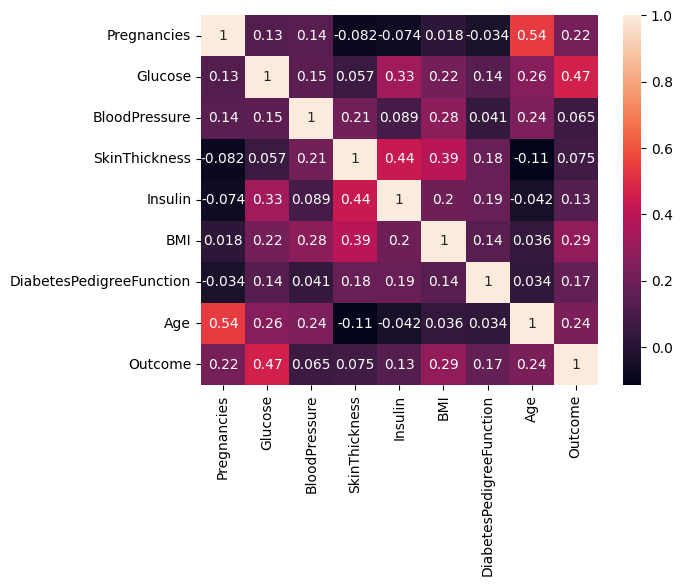

In [15]:
sns.heatmap(df.corr(),annot=True)

### Observations:
1. SkintThickness is highly positively correlated to the outcome(diebities)
2. BloodPressure is also highly positively correlated to the outcome(diebities)
3. Glucose is also highly positively correlated to the outcome(diebities)


## 2. Data Preprocessing:

### a. Handle missing values (e.g., imputation).

In [16]:
df[df["BMI"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.0,0.232,54,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
684,5,136,82,0,0,0.0,0.640,69,0


In [17]:
#  As there are outliers also present in the  columns so we will use median to fill the 0 value of columns , as median is robust to outliers
from sklearn.impute import SimpleImputer
dependentcol=["Outcome"]
for col in df.columns:
    if (df[col].dtype == 'int64' or df[col].dtype == 'float64') and (col not in dependentcol):
      df[col] = df[col].replace(0, np.nan)
      imputer = SimpleImputer(strategy='median')
      df[col] = imputer.fit_transform(df[[col]])


In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,4.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [19]:
# We need to scale the data cause the features in data have different scale so, i will use standardscaler to scale down the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df.drop("Outcome",axis=1))

In [20]:
X_scaled

array([[ 0.52939452,  0.86604475, -0.03198993, ...,  0.16661938,
         0.46849198,  1.4259954 ],
       [-1.14928009, -1.20506583, -0.5283186 , ..., -0.85219976,
        -0.36506078, -0.19067191],
       [ 1.20086436,  2.01666174, -0.69376149, ..., -1.33250021,
         0.60439732, -0.10558415],
       ...,
       [ 0.1936596 , -0.02157407, -0.03198993, ..., -0.910418  ,
        -0.68519336, -0.27575966],
       [-1.14928009,  0.14279979, -1.02464727, ..., -0.34279019,
        -0.37110101,  1.17073215],
       [-1.14928009, -0.94206766, -0.19743282, ..., -0.29912651,
        -0.47378505, -0.87137393]])

### b. Encode categorical variables.

### As There are no categorical columns,there are only int,float columns so

## 3. Model Building:

In [21]:
from sklearn.linear_model import  LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score, roc_curve
)

In [22]:
# Creating the instance of the model
cls=LogisticRegression()

In [23]:
# Creating X,y (Independent, dependent)
X=X_scaled
y=df["Outcome"].values

In [24]:
X

array([[ 0.52939452,  0.86604475, -0.03198993, ...,  0.16661938,
         0.46849198,  1.4259954 ],
       [-1.14928009, -1.20506583, -0.5283186 , ..., -0.85219976,
        -0.36506078, -0.19067191],
       [ 1.20086436,  2.01666174, -0.69376149, ..., -1.33250021,
         0.60439732, -0.10558415],
       ...,
       [ 0.1936596 , -0.02157407, -0.03198993, ..., -0.910418  ,
        -0.68519336, -0.27575966],
       [-1.14928009,  0.14279979, -1.02464727, ..., -0.34279019,
        -0.37110101,  1.17073215],
       [-1.14928009, -0.94206766, -0.19743282, ..., -0.29912651,
        -0.47378505, -0.87137393]])

In [25]:
y

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [26]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Training The Model
cls.fit(X_train,y_train)

LogisticRegression()

In [28]:
# Making Predictions
y_pred=cls.predict(X_test)
y_pred_proba = cls.predict_proba(X_test)[:,1]  # probability prediction for ROC

In [29]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

In [30]:
y_pred_proba

array([0.27202786, 0.1576588 , 0.10228823, 0.15234682, 0.45840569,
       0.43179173, 0.01368355, 0.44155188, 0.5665288 , 0.76081132,
       0.22370095, 0.89092125, 0.36863165, 0.2742386 , 0.07491785,
       0.39251239, 0.10696085, 0.071246  , 0.71814158, 0.62659355,
       0.18549088, 0.07164265, 0.51702784, 0.08887337, 0.55341978,
       0.88243254, 0.10563926, 0.02801312, 0.24357284, 0.10212767,
       0.93888691, 0.85437232, 0.80740168, 0.71007364, 0.55784366,
       0.71517803, 0.97467326, 0.24650389, 0.45719254, 0.53991153,
       0.06382867, 0.56051702, 0.50711904, 0.30793222, 0.02557363,
       0.54543591, 0.64276328, 0.18349152, 0.33493665, 0.96807897,
       0.03873588, 0.68868112, 0.83656498, 0.23408582, 0.1282978 ,
       0.0377993 , 0.76991715, 0.04570077, 0.40418844, 0.75672994,
       0.72200247, 0.29955167, 0.19621885, 0.19272407, 0.09186211,
       0.6744141 , 0.03752882, 0.70712391, 0.04405337, 0.77086533,
       0.71654165, 0.05178494, 0.16048401, 0.13294715, 0.08387

## 4. Model Evaluation:

In [31]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7597402597402597
Precision: 0.6730769230769231
Recall   : 0.6363636363636364
F1-score : 0.6542056074766355


###  ROC Curve

In [32]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

ROC-AUC Score: 0.8240587695133148


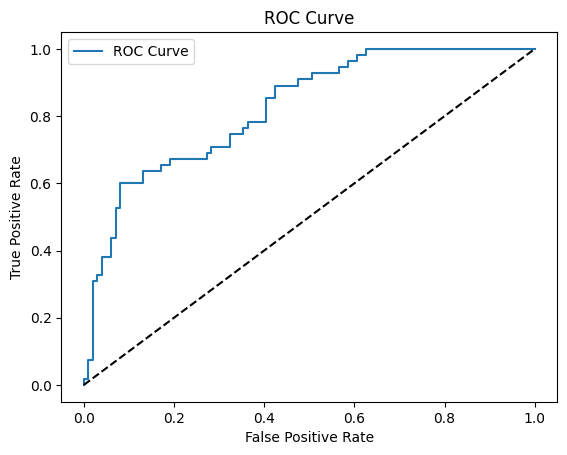

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

##5. Interpretation:

In [34]:
cls.coef_

array([[ 0.21404481,  1.11193503, -0.16089134,  0.07133424, -0.13269575,
         0.67043584,  0.19902459,  0.41541471]])

In [35]:
coefficients = pd.DataFrame({
    'Feature': df.drop("Outcome",axis=1).columns,
    'Coefficient': cls.coef_[0]
})

coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])

print(coefficients)

                    Feature  Coefficient  Odds_Ratio
0               Pregnancies     0.214045    1.238678
1                   Glucose     1.111935    3.040236
2             BloodPressure    -0.160891    0.851385
3             SkinThickness     0.071334    1.073940
4                   Insulin    -0.132696    0.875731
5                       BMI     0.670436    1.955089
6  DiabetesPedigreeFunction     0.199025    1.220212
7                       Age     0.415415    1.514999


* Interpretation of results
1. This is the strongest predictor. For every one-unit increase in glucose, the odds of having the outcome increase by approximately 204% (3.04 - 1).

2. BMI: For each one-unit increase in BMI, the odds of the outcome increase by about 95% (1.95 - 1).

3. Age: For each additional year of age, the odds of the outcome increase by about 51% (1.51 - 1).

In [36]:
import pickle

# Saveing the model
with open('logistic_regression_model.pkl', 'wb') as model_file:
    pickle.dump(cls, model_file)

# Save the scaler because we scaled data using Standard scalar before training the model,
#saving the scalar makes sure that the same scaling transformation to apply to new data before feeding it to the loaded model for predictions,maintaining consistenct and accurate results
with open('scaler.pkl', 'wb') as scaler_file: 
    pickle.dump(scaler, scaler_file)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
